In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Settings
# -------------------------------------------------------------------
DATA_DIR = "Nov_25"            # folder where your CSVs live
PLOT_DIR = "Nov_25_Plots"         # folder to save all plots
os.makedirs(PLOT_DIR, exist_ok=True)
calib = []

# (Re, Ri, Cm, CSV name, short label)
configs = [
    # {
    #     "Re": 43.0,
    #     "Ri": 43.0,
    #     "Cm": 62e-9,
    #     "csv": "43+43+62(68)nf.csv",
    #     "label": "43_43_62nF",
    # },
    {
        "Re": 82.0,
        "Ri": 82.0,
        "Cm": 100e-9,
        "csv": "82+82+100nf.csv",       # <-- adjust if your filename differs
        "label": "82_82_100nF",
    },
    {
        "Re": 330.0,
        "Ri": 240.0,
        "Cm": 22e-9,
        "csv": "330+240+22nf.csv",     # <-- adjust if your filename differs
        "label": "330_240_22nF",
    },
]


def add_reference_columns(df, Re, Ri, Cm):
    """
    Compute reference complex impedance for each row using:
        Z = Re + (Ri || 1 / (j ω Cm))
    and add Ref_R, Ref_Xc, Ref_Z, Ref_PhA columns.
    """
    w = 2 * np.pi * df["Freq_Hz"].values
    j = 1j

    Zc = 1 / (j * w * Cm)           # capacitor impedance
    Zp = 1 / (1 / Ri + 1 / Zc)      # parallel (Ri || C)
    Z  = Re + Zp                    # series Re + parallel branch

    df["Ref_R"]   = Z.real
    df["Ref_Xc"]  = Z.imag
    df["Ref_Z"]   = np.abs(Z)
    df["Ref_PhA"] = np.degrees(np.arctan2(df["Ref_Xc"], df["Ref_R"]))
    return df


def plot_error(df, y_col, ylabel, limit, base_name):
    """
    Plot abs error vs freq for all (Current, Gain) combos and save.
    """
    plt.figure(figsize=(9, 5))
    for (current, gain), grp in df.groupby(["Current", "Gain"]):
        label = f"{current}_{gain}"
        grp_sorted = grp.sort_values("Freq_Hz")
        plt.plot(
            grp_sorted["Freq_Hz"],
            grp_sorted[y_col],
            marker="o",
            linestyle="-",
            label=label,
        )

    # Tolerance band (±limit)
    plt.axhline(limit, linestyle="--")
    plt.axhline(-limit, linestyle="--")

    plt.xscale("log")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs frequency ({base_name})")
    plt.grid(True, which="both", ls=":")
    plt.legend()
    plt.tight_layout()

    safe_label = (
        ylabel.replace(" ", "_")
              .replace("(", "")
              .replace(")", "")
              .replace("°", "deg")
    )
    fname = f"{safe_label}_{base_name}.png"
    plt.savefig(os.path.join(PLOT_DIR, fname), dpi=300)
    plt.close()


def plot_cole_cole(df, base_name):
    """
    Cole–Cole (Nyquist) plot: Real vs -Imag.
    Show reference curve and measured points per (Current, Gain).
    """
    plt.figure(figsize=(6, 6))

    # Measured data by group
    for (current, gain), grp in df.groupby(["Current", "Gain"]):
        label = f"Meas {current}_{gain}"
        plt.plot(
            grp["Load_Real"],
            -grp["Load_Imag"],
            marker="o",
            linestyle="",
            label=label,
            alpha=0.7,
        )

    # Reference curve (all freqs)
    df_sorted = df.sort_values("Freq_Hz")
    plt.plot(
        df_sorted["Ref_R"],
        -df_sorted["Ref_Xc"],
        "k-",
        label="Reference model",
        linewidth=2,
    )

    plt.xlabel("Real(Z) [Ω]")
    plt.ylabel("-Imag(Z) [Ω]")
    plt.title(f"Cole–Cole plot ({base_name})")
    plt.grid(True)
    plt.axis("equal")
    plt.legend()
    plt.tight_layout()

    fname = f"ColeCole_{base_name}.png"
    plt.savefig(os.path.join(PLOT_DIR, fname), dpi=300)
    plt.close()


# -------------------------------------------------------------------
# Main loop over all (Re, Ri, Cm) configurations
# -------------------------------------------------------------------
for cfg in configs:
    Re = cfg["Re"]
    Ri = cfg["Ri"]
    Cm = cfg["Cm"]
    csv_path = os.path.join(DATA_DIR, cfg["csv"])
    label = cfg["label"]

    print(f"\n=== {label}: Re={Re} Ω, Ri={Ri} Ω, Cm={Cm*1e9:.2f} nF ===")

    # 1. Load data
    df = pd.read_csv(csv_path)

    # Limit frequency range if desired
    df = df[(df["Freq_Hz"] >= 1000) & (df["Freq_Hz"] <= 500000)]

    # 2. Reference values from Cole–Cole model
    df = add_reference_columns(df, Re, Ri, Cm)

    # 3. Absolute errors
    df["Err_R"]   = np.abs(df["Load_Real"]   - df["Ref_R"])
    df["Err_Xc"]  = np.abs(df["Load_Imag"]   - df["Ref_Xc"])
    df["Err_Z"]   = np.abs(df["Load_Mag"]    - df["Ref_Z"])
    df["Err_PhA"] = np.abs(df["Load_Angle"]  - df["Ref_PhA"])

    calib.append(df['Calib_Ohm'].unique())
    # 4. Mean & std error per (Current, Gain)
    stats = (
        df.groupby(["Current", "Gain"])[["Err_R", "Err_Z", "Err_Xc", "Err_PhA"]]
          .agg(["mean", "std"])
          .round(3)
    )

    print(stats)

    # 5. Save Cole–Cole and error plots
    plot_cole_cole(df, label)
    plot_error(df, "Err_R",   "R error (ohm)",           limit=3.0,  base_name=label)
    plot_error(df, "Err_Z",   "Z error (ohm)",           limit=3.0,  base_name=label)
    plot_error(df, "Err_Xc",  "Xc error (ohm)",          limit=1.0,  base_name=label)
    plot_error(df, "Err_PhA", "Phase angle error (deg)", limit=0.2,  base_name=label)
    print("List of calibration resistors used in tests:", df['Calib_Ohm'].unique())


=== 82_82_100nF: Re=82.0 Ω, Ri=82.0 Ω, Cm=100.00 nF ===
              Err_R         Err_Z        Err_Xc        Err_PhA       
               mean    std   mean    std   mean    std    mean    std
Current Gain                                                         
1.28mA  x2    0.825  0.080  0.903  0.109  0.380  0.116   0.052  0.052
        x5    0.496  0.973  0.534  0.954  0.954  1.937   0.642  1.399
128uA   x10   0.534  0.376  0.733  0.512  1.140  0.518   0.539  0.267
256uA   x10   0.359  0.301  0.450  0.347  0.559  0.307   0.275  0.182
640uA   x10   0.207  0.183  0.240  0.207  0.426  0.199   0.267  0.140
        x5    0.525  0.231  0.553  0.291  0.282  0.248   0.088  0.077
64uA    x10   0.972  0.743  1.502  0.989  2.644  0.911   1.202  0.408
List of calibration resistors used in tests: [168 136 100]

=== 330_240_22nF: Re=330.0 Ω, Ri=240.0 Ω, Cm=22.00 nF ===
               Err_R         Err_Z        Err_Xc        Err_PhA       
                mean    std   mean    std   mean    st

In [14]:
df

,Current,Freq_Hz,Calib_Ohm,Gain,Load_Real,Load_Imag,Load_Mag,Load_Angle,Overload,I_ADC,Q_ADC,Ref_R,Ref_Xc,Ref_Z,Ref_PhA,Err_R,Err_Xc,Err_Z,Err_PhA
0,64uA,1000,1034,x5,1032.150,-8.86038,1032.190,-0.491837,0,146761,1172,1029.980163,-3.053374,1029.984689,-0.169853,2.169837,5.807006,2.205311,0.321984
1,64uA,2000,1034,x5,1031.360,-11.93200,1031.430,-0.662837,0,146526,341,1029.920661,-6.105974,1029.938761,-0.339679,1.439339,5.826026,1.491239,0.323158
2,64uA,3000,1034,x5,1032.100,-15.97560,1032.230,-0.886795,0,146148,-537,1029.821525,-9.157029,1029.862236,-0.509453,2.278475,6.818571,2.367764,0.377342
3,64uA,4000,1034,x5,1030.340,-19.64000,1030.530,-1.092020,0,146209,-1064,1029.682806,-12.205767,1029.755146,-0.679147,0.657194,7.434233,0.774854,0.412873
4,64uA,5000,1034,x5,1030.440,-18.32550,1030.600,-1.018850,0,146104,-1467,1029.504572,-15.251418,1029.617535,-0.848736,0.935428,3.074082,0.982465,0.170114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,1.28mA,300032,660,x1,649.446,-152.94300,667.212,-13.251500,0,142583,-229544,657.925168,-190.880828,685.055485,-16.178788,8.479168,37.937828,17.843485,2.927288
181,1.28mA,350208,624,x1,607.373,-137.95500,622.844,-12.796700,0,118928,-213562,636.092420,-173.128222,659.232090,-15.225643,28.719420,35.173222,36.388090,2.428943
182,1.28mA,399872,624,x1,601.428,-116.12800,612.537,-10.928600,0,97406,-194995,620.652577,-157.568956,640.341782,-14.245081,19.224577,41.440956,27.804782,3.316481
183,1.28mA,449536,588,x1,588.509,-101.18700,597.144,-9.755900,0,75007,-175338,609.319901,-144.041317,626.113922,-13.300374,20.810901,42.854317,28.969922,3.544474


In [ ]:
# List of calibration resistors used in tests: [1034  998  966  930  914  878  846  810  764  728  696  660  624  588]
# List of calibration resistors used in tests: [100, 168, 354, 318, 624, 588, 846, 1034, 1080, 1184]

####################################


In [77]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# ---------------------------------------------------------
# Settings
# ---------------------------------------------------------
BASE_FOLDER = "Nov_25"          # where the CSVs live
PLOT_FOLDER = "Nov_25_ErrorPlots"          # where to save plots
os.makedirs(PLOT_FOLDER, exist_ok=True)
calib = []
# All reference resistor values (filename pattern: "<R>ohm.csv")
ref_values = [101, 284, 535, 989]


# Per-current minimum frequency constraints (Hz)
FREQ_MIN_BY_CURRENT = {
    "64uA":   1_000,   # all freqs in 1 kHz–500 kHz
    "128uA":  1_000,   # all freqs in 1 kHz–500 kHz
    "256uA":  5_000,   # 5 kHz and above
    "640uA":  10_000,  # 10 kHz and above
    "1.28mA": 20_000,  # 20 kHz and above
}


def process_resistor(ref_R: int):
    """
    Load data for given reference resistor, apply per-current frequency limits,
    compute abs errors, print mean & std per (Current, Gain), save plots and
    a per-frequency error table.
    """
    csv_path = os.path.join(BASE_FOLDER, f"{ref_R}ohm.csv")
    print(f"\n=== Processing {csv_path} (Ref = {ref_R} ohm) ===")

    # 1. Load data
    df = pd.read_csv(csv_path)

    # Basic global band: 1 kHz – 500 kHz
    df = df[(df["Freq_Hz"] >= 1000) & (df["Freq_Hz"] <= 500000)]

    # 2. Reference values (ideal resistor)
    df["Ref_R"]   = float(ref_R)
    df["Ref_Xc"]  = 0.0
    df["Ref_Z"]   = float(ref_R)
    df["Ref_PhA"] = 0.0

    # 3. Absolute errors: |measured – reference|
    df["Err_R"]   = np.abs(df["Load_Real"]  - df["Ref_R"])
    df["Err_Xc"]  = np.abs(df["Load_Imag"]  - df["Ref_Xc"])
    df["Err_Z"]   = np.abs(df["Load_Mag"]   - df["Ref_Z"])
    df["Err_PhA"] = np.abs(df["Load_Angle"] - df["Ref_PhA"])

    # 4. Apply per-current frequency limits
    #    (64uA, 128uA: all freqs; 256uA: >=5k; 640uA: >=10k; 1.28mA: >=20k)
    filtered_parts = []
    for current, grp in df.groupby("Current"):
        fmin = FREQ_MIN_BY_CURRENT.get(current, 1000)  # default to 1 kHz
        filtered = grp[grp["Freq_Hz"] >= fmin]
        filtered_parts.append(filtered)

    df = pd.concat(filtered_parts, ignore_index=True)

    # 5. Show calibration resistors used
    print("Calibration Resistors", df["Calib_Ohm"].unique())
    calib.append(df["Calib_Ohm"].unique())

    # 6. Mean & std error per (Current, Gain) after filtering
    group_stats = (
        df.groupby(["Current", "Gain"])[["Err_R", "Err_Z"]]
          .agg(["mean", "std"])
          .round(3)
    )

    print(f"Reference R = {ref_R} ohm")
    print(group_stats)
    print()

    # 7. Per-frequency error table (for later analysis)
    #    Mean error per (Current, Gain, Freq_Hz)
    per_freq_stats = (
        df.groupby(["Current", "Gain", "Freq_Hz"])
          [["Err_R", "Err_Z", "Err_Xc", "Err_PhA"]]
          .mean()
          .reset_index()
          .sort_values(["Current", "Gain", "Freq_Hz"])
    )

    csv_out = os.path.join(
        PLOT_FOLDER,
        f"per_freq_errors_{ref_R}ohm.csv"
    )
    per_freq_stats.to_csv(csv_out, index=False)

    # 8. Plot helper (save instead of show)
    def plot_error(y_col, ylabel, limit):
        plt.figure(figsize=(9, 5))
        for (current, gain), grp in df.groupby(["Current", "Gain"]):
            label = f"{current}_{gain}"
            grp_sorted = grp.sort_values("Freq_Hz")
            plt.plot(
                grp_sorted["Freq_Hz"],
                grp_sorted[y_col],
                marker="o",
                linestyle="-",
                label=label,
            )

        # Tolerance band (since errors are abs, only +limit really matters,
        # but we keep ±limit for visual reference)
        plt.axhline(limit, linestyle="--")
        plt.axhline(-limit, linestyle="--")

        plt.xscale("log")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel(ylabel)
        plt.title(f"{ylabel} vs frequency (Ref {ref_R} Ω)")
        plt.grid(True, which="both", ls=":")
        plt.legend()
        plt.tight_layout()

        safe_label = (
            ylabel.replace(" ", "_")
                  .replace("(", "")
                  .replace(")", "")
                  .replace("°", "deg")
        )
        fname = f"{safe_label}_{ref_R}ohm.png"
        full_path = os.path.join(PLOT_FOLDER, fname)
        # plt.savefig(full_path, dpi=300)
        plt.close()

    # 9. Generate & save the four plots (all obey the per-current freq limits)
    plot_error("Err_R",   "R error (ohm)",           limit=3.0)
    plot_error("Err_Z",   "Z error (ohm)",           limit=3.0)
    plot_error("Err_Xc",  "Xc error (ohm)",          limit=1.0)
    plot_error("Err_PhA", "Phase angle error (deg)", limit=0.2)


# ---------------------------------------------------------
# Run for all resistor values
# ---------------------------------------------------------
for ref in ref_values:
    process_resistor(ref)

print("List of calibration resistors used in tests:", calib)



=== Processing Nov_25\101ohm.csv (Ref = 101 ohm) ===
Calibration Resistors [100]
Reference R = 101 ohm
              Err_R         Err_Z       
               mean    std   mean    std
Current Gain                            
1.28mA  x2    0.633  0.142  0.631  0.141
128uA   x10   0.486  0.569  0.479  0.567
256uA   x10   0.674  0.264  0.670  0.265
640uA   x5    0.721  0.051  0.720  0.051
64uA    x10   0.420  0.354  0.439  0.383


=== Processing Nov_25\284ohm.csv (Ref = 284 ohm) ===
Calibration Resistors [286]
Reference R = 284 ohm
              Err_R         Err_Z       
               mean    std   mean    std
Current Gain                            
1.28mA  x1    1.014  0.712  1.016  0.714
128uA   x10   0.266  0.222  0.269  0.223
256uA   x5    0.265  0.263  0.264  0.263
640uA   x2    0.369  0.234  0.372  0.233
64uA    x10   0.677  0.564  0.690  0.572


=== Processing Nov_25\535ohm.csv (Ref = 535 ohm) ===
Calibration Resistors [520]
Reference R = 535 ohm
              Err_R         Er

Saved band plots to: Nov_25_BandPlots


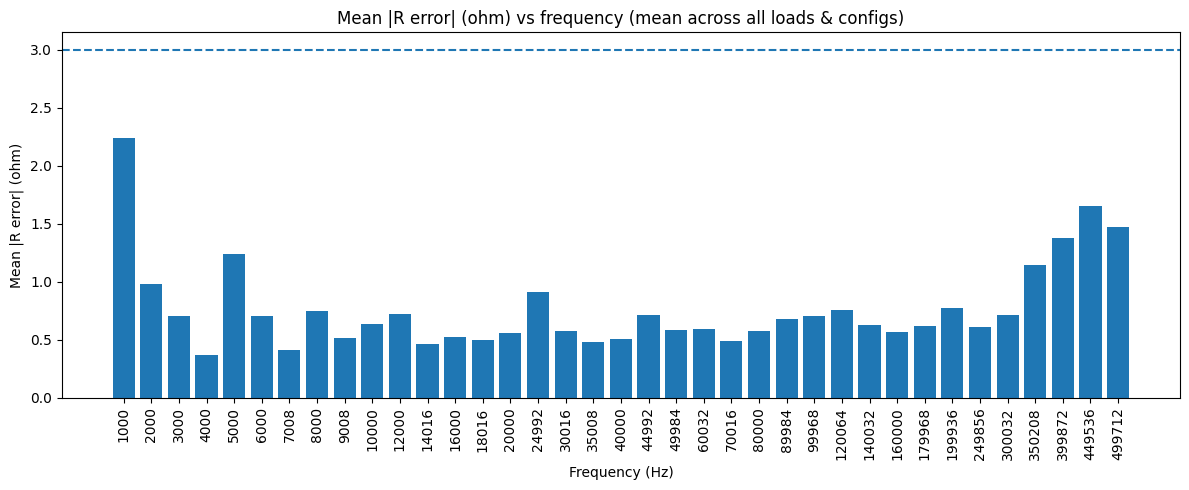

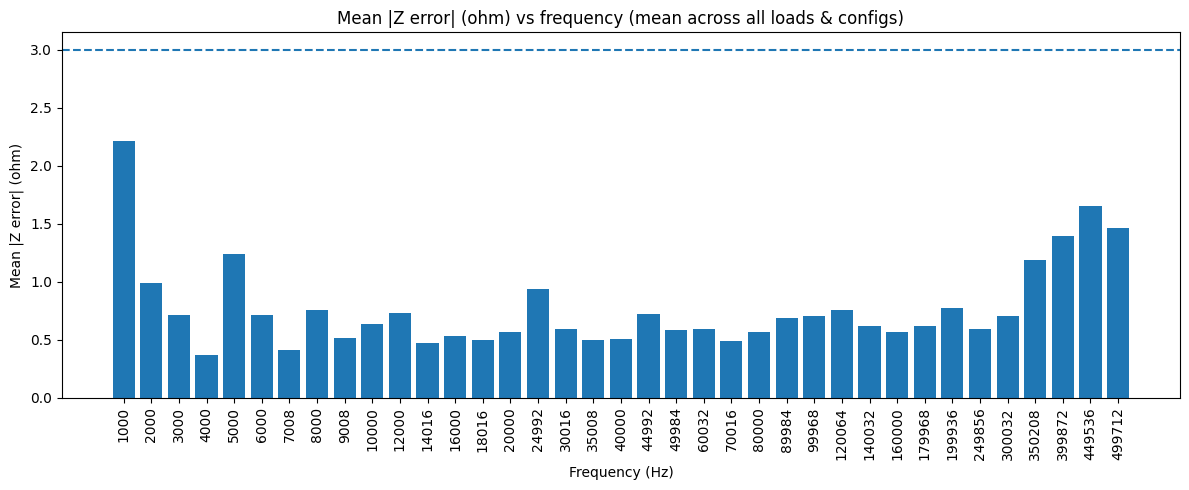

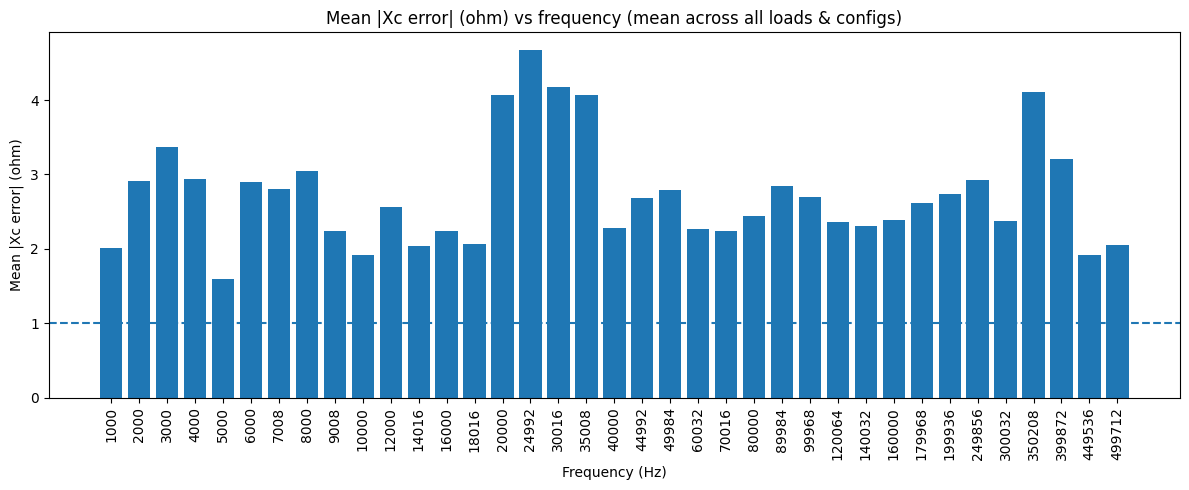

In [5]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Settings
# ---------------------------------------------------------
PLOT_FOLDER = "Nov_25_ErrorPlots"     # same folder where per_freq_errors_*.csv were saved
OUT_FOLDER  = "Nov_25_BandPlots"      # where to save the combined band plots
os.makedirs(OUT_FOLDER, exist_ok=True)

# ---------------------------------------------------------
# 1. Load all per-frequency error CSVs and concatenate
# ---------------------------------------------------------
pattern = os.path.join(PLOT_FOLDER, "per_freq_errors_*ohm.csv")
files = glob.glob(pattern)

if not files:
    raise FileNotFoundError(
        f"No per_freq_errors_*ohm.csv files found in {PLOT_FOLDER}. "
        f"Run the per-frequency generation script first."
    )

dfs = [pd.read_csv(f) for f in files]
df_all = pd.concat(dfs, ignore_index=True)

# ---------------------------------------------------------
# 2. Aggregate across loads & configs per frequency
# ---------------------------------------------------------
# At this point df_all has columns:
#   Current, Gain, Freq_Hz, Err_R, Err_Z, Err_Xc, Err_PhA
# The per-frequency CSVs already respect the current-specific
# frequency limits you imposed earlier.

agg = (
    df_all
    .groupby("Freq_Hz")[["Err_R", "Err_Z", "Err_Xc"]]
    .mean()
    .reset_index()
)

# Sort by frequency for nicer plotting
agg = agg.sort_values("Freq_Hz")

# For bar labels: use string version of frequency (or you can keep numeric on x-axis)
freq_labels = agg["Freq_Hz"].astype(int).astype(str)

# ---------------------------------------------------------
# 3. Helper to make a bar plot for a given error metric
# ---------------------------------------------------------
def plot_bar(metric_col, ylabel, out_name, limit=None):
    plt.figure(figsize=(12, 5))

    plt.bar(freq_labels, agg[metric_col])

    # Optional horizontal spec line (e.g., 3 Ω for R/Z, 1 Ω for Xc)
    if limit is not None:
        plt.axhline(limit, linestyle="--")

    plt.xticks(rotation=90)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs frequency (mean across all loads & configs)")
    plt.tight_layout()

    out_path = os.path.join(OUT_FOLDER, out_name)
    # plt.savefig(out_path, dpi=300)
    # plt.close()

# ---------------------------------------------------------
# 4. Make the three requested plots
# ---------------------------------------------------------
# One graph for R
plot_bar("Err_R", "Mean |R error| (ohm)", "bandplot_R_error.png", limit=3.0)

# One graph for Z
plot_bar("Err_Z", "Mean |Z error| (ohm)", "bandplot_Z_error.png", limit=3.0)

# One graph for Xc
plot_bar("Err_Xc", "Mean |Xc error| (ohm)", "bandplot_Xc_error.png", limit=1.0)

print("Saved band plots to:", OUT_FOLDER)


In [72]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Settings
# -------------------------------------------------------------------
DATA_DIR = "Nov_25"            # folder where your CSVs live
PLOT_DIR = "Nov_25_Plots"         # folder to save all plots
os.makedirs(PLOT_DIR, exist_ok=True)
calib = []

# (Re, Ri, Cm, CSV name, short label)
configs = [
    # {
    #     "Re": 43.0,
    #     "Ri": 43.0,
    #     "Cm": 62e-9,
    #     "csv": "43+43+62(68)nf.csv",
    #     "label": "43_43_62nF",
    # },
    {
        "Re": 82.0,
        "Ri": 82.0,
        "Cm": 100e-9,
        "csv": "82+82+100nf.csv",       # <-- adjust if your filename differs
        "label": "82_82_100nF",
    }
    # {
    #     "Re": 330.0,
    #     "Ri": 240.0,
    #     "Cm": 22e-9,
    #     "csv": "330+240+22nf.csv",     # <-- adjust if your filename differs
    #     "label": "330_240_22nF",
    # },
]


def add_reference_columns(df, Re, Ri, Cm):
    """
    Compute reference complex impedance for each row using:
        Z = Re + (Ri || 1 / (j ω Cm))
    and add Ref_R, Ref_Xc, Ref_Z, Ref_PhA columns.
    """
    w = 2 * np.pi * df["Freq_Hz"].values
    j = 1j

    Zc = 1 / (j * w * Cm)           # capacitor impedance
    Zp = 1 / (1 / Ri + 1 / Zc)      # parallel (Ri || C)
    Z  = Re + Zp                    # series Re + parallel branch

    df["Ref_R"]   = Z.real
    df["Ref_Xc"]  = Z.imag
    df["Ref_Z"]   = np.abs(Z)
    df["Ref_PhA"] = np.degrees(np.arctan2(df["Ref_Xc"], df["Ref_R"]))
    return df


def plot_error(df, y_col, ylabel, limit, base_name):
    """
    Plot abs error vs freq for all (Current, Gain) combos and save.
    """
    plt.figure(figsize=(9, 5))
    for (current, gain), grp in df.groupby(["Current", "Gain"]):
        label = f"{current}_{gain}"
        grp_sorted = grp.sort_values("Freq_Hz")
        plt.plot(
            grp_sorted["Freq_Hz"],
            grp_sorted[y_col],
            marker="o",
            linestyle="-",
            label=label,
        )

    # Tolerance band (±limit)
    plt.axhline(limit, linestyle="--")
    plt.axhline(-limit, linestyle="--")

    plt.xscale("log")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs frequency ({base_name})")
    plt.grid(True, which="both", ls=":")
    plt.legend()
    plt.tight_layout()

    safe_label = (
        ylabel.replace(" ", "_")
              .replace("(", "")
              .replace(")", "")
              .replace("°", "deg")
    )
    fname = f"{safe_label}_{base_name}.png"
    plt.savefig(os.path.join(PLOT_DIR, fname), dpi=300)
    plt.close()


def plot_cole_cole(df, base_name):
    """
    Cole–Cole (Nyquist) plot: Real vs -Imag.
    Show reference curve and measured points per (Current, Gain).
    """
    plt.figure(figsize=(6, 6))

    # Measured data by group
    for (current, gain), grp in df.groupby(["Current", "Gain"]):
        label = f"Meas {current}_{gain}"
        plt.plot(
            grp["Load_Real"],
            -grp["Load_Imag"],
            marker="o",
            linestyle="",
            label=label,
            alpha=0.7,
        )

    # Reference curve (all freqs)
    df_sorted = df.sort_values("Freq_Hz")
    plt.plot(
        df_sorted["Ref_R"],
        -df_sorted["Ref_Xc"],
        "k-",
        label="Reference model",
        linewidth=2,
    )

    plt.xlabel("Real(Z) [Ω]")
    plt.ylabel("-Imag(Z) [Ω]")
    plt.title(f"Cole–Cole plot ({base_name})")
    plt.grid(True)
    plt.axis("equal")
    plt.legend()
    plt.tight_layout()

    fname = f"ColeCole_{base_name}.png"
    # plt.savefig(os.path.join(PLOT_DIR, fname), dpi=300)
    plt.close()


# -------------------------------------------------------------------
# Main loop over all (Re, Ri, Cm) configurations
# -------------------------------------------------------------------
for cfg in configs:
    Re = cfg["Re"]
    Ri = cfg["Ri"]
    Cm = cfg["Cm"]
    csv_path = os.path.join(DATA_DIR, cfg["csv"])
    label = cfg["label"]

    print(f"\n=== {label}: Re={Re} Ω, Ri={Ri} Ω, Cm={Cm*1e9:.2f} nF ===")

    # 1. Load data
    df = pd.read_csv(csv_path)

    # Limit frequency range if desired
    df = df[(df["Freq_Hz"] >= 1000) & (df["Freq_Hz"] <= 500000)]

    # 2. Reference values from Cole–Cole model
    df = add_reference_columns(df, Re, Ri, Cm)

    # 3. Absolute errors
    df["Err_R"]   = np.abs(df["Load_Real"]   - df["Ref_R"])
    df["Err_Xc"]  = np.abs(df["Load_Imag"]   - df["Ref_Xc"])
    df["Err_Z"]   = np.abs(df["Load_Mag"]    - df["Ref_Z"])
    df["Err_PhA"] = np.abs(df["Load_Angle"]  - df["Ref_PhA"])

    calib.append(df['Calib_Ohm'].unique())
    # 4. Mean & std error per (Current, Gain)
    stats = (
        df.groupby(["Current", "Gain"])[["Err_R", "Err_Z", "Err_Xc", "Err_PhA"]]
          .agg(["mean", "std"])
          .round(3)
    )

    print(stats)

    # 5. Save Cole–Cole and error plots
    plot_cole_cole(df, label)
    plot_error(df, "Err_R",   "R error (ohm)",           limit=3.0,  base_name=label)
    plot_error(df, "Err_Z",   "Z error (ohm)",           limit=3.0,  base_name=label)
    plot_error(df, "Err_Xc",  "Xc error (ohm)",          limit=1.0,  base_name=label)
    plot_error(df, "Err_PhA", "Phase angle error (deg)", limit=0.2,  base_name=label)
    print("List of calibration resistors used in tests:", df['Calib_Ohm'].unique())


=== 82_82_100nF: Re=82.0 Ω, Ri=82.0 Ω, Cm=100.00 nF ===
              Err_R         Err_Z        Err_Xc        Err_PhA       
               mean    std   mean    std   mean    std    mean    std
Current Gain                                                         
1.28mA  x2    0.825  0.080  0.903  0.109  0.380  0.116   0.052  0.052
        x5    0.496  0.973  0.534  0.954  0.954  1.937   0.642  1.399
128uA   x10   0.534  0.376  0.733  0.512  1.140  0.518   0.539  0.267
256uA   x10   0.359  0.301  0.450  0.347  0.559  0.307   0.275  0.182
640uA   x10   0.207  0.183  0.240  0.207  0.426  0.199   0.267  0.140
        x5    0.525  0.231  0.553  0.291  0.282  0.248   0.088  0.077
64uA    x10   0.972  0.743  1.502  0.989  2.644  0.911   1.202  0.408
List of calibration resistors used in tests: [168 136 100]


In [73]:
reac = df.groupby(['Current', 'Gain'])['Load_Imag'].apply(list)
real = df.groupby(['Current', 'Gain'])['Load_Real'].apply(list)
reac, real

reac_ref = df.groupby(['Current', 'Gain'])['Ref_Xc'].apply(list)
reac_real = df.groupby(['Current', 'Gain'])['Ref_R'].apply(list)

C:\Users\delphic\AppData\Local\Temp\ipykernel_22568\3107361653.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(real[-1], np.multiply(-1, reac[-1]), marker='o')
C:\Users\delphic\AppData\Local\Temp\ipykernel_22568\3107361653.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(reac_real[-1], np.multiply(-1, reac_ref[-1]), c='k', marker='o')
C:\Users\delphic\AppData\Local\Temp\ipykernel_22568\3107361653.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access

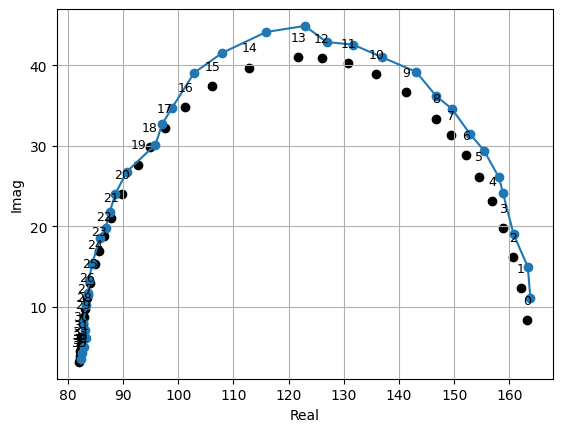

In [74]:
plt.figure()
plt.plot(real[-1], np.multiply(-1, reac[-1]), marker='o')
plt.scatter(reac_real[-1], np.multiply(-1, reac_ref[-1]), c='k', marker='o')

# # Label each point with its index (0,1,2,...)
# for i, (x, y) in enumerate(zip(real[-1], np.multiply(-1, reac[-1]))):
#     plt.text(x, y + 0.02, str(i), ha='center', fontsize=9)

for i, (x, y) in enumerate(zip(reac_real[-1], np.multiply(-1, reac_ref[-1]))):
    plt.text(x, y + 2, str(i), ha='center', fontsize=9)

plt.xlabel("Real")
plt.ylabel("Imag")
plt.grid(True)
plt.show()

Cole–Cole Plot & Circle Fit Simulated : center=(123.0, -0.0), radius=41.0, R0=164.0, Rinf=82.0


C:\Users\delphic\AppData\Local\Temp\ipykernel_22568\1852363468.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plot_cole_circle(np.asarray(reac_real[-1]), np.multiply(-1, reac_ref[-1]), title='Cole–Cole Plot & Circle Fit Simulated')


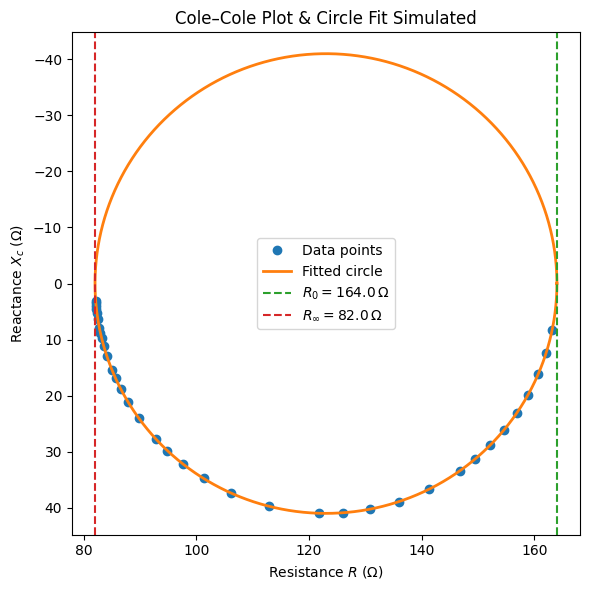

C:\Users\delphic\AppData\Local\Temp\ipykernel_22568\1852363468.py:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plot_cole_circle(np.asarray(real[-1]), np.multiply(-1, reac[-1]), title='Cole–Cole Plot & Circle Fit PCB V2')


Cole–Cole Plot & Circle Fit PCB V2 : center=(123.8, 2.8), radius=41.0, R0=164.7, Rinf=82.9


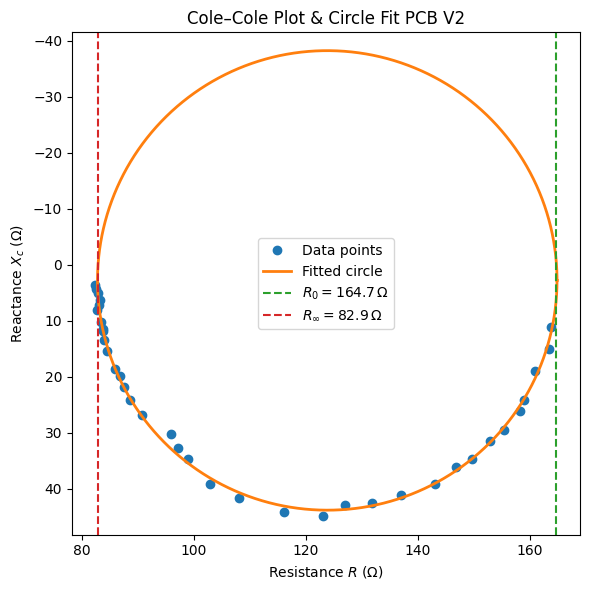

In [79]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

def cole_circle_fit(R, X):
    # — Stage A: Kåsa linear init —
    A = np.column_stack([R, X, np.ones_like(R)])
    B = -(R**2 + X**2)
    D, E, F = np.linalg.lstsq(A, B, rcond=None)[0]
    a0, b0 = -D/2, -E/2
    c0 = np.mean(np.sqrt((R-a0)**2 + (X-b0)**2))
    
    # — Stage B: orthogonal‐distance refine —
    def resid(p, R, X):
        a, b, c = p
        return (R-a)**2 + (X-b)**2 - c**2
    init = np.array([a0, b0, c0])
    res = least_squares(resid, init, args=(R, X), xtol=1e-12, ftol=1e-12)
    a, b, c = res.x
    
    # intercepts
    delta = math.sqrt(max(c*c - b*b, 0.0))
    R0   = a + delta
    Rinf = a - delta
    
    return (a, b, c, R0, Rinf)

def plot_cole_circle(R, X, title='Cole–Cole Circle Fit'):
    # fit circle
    a, b, c, R0, Rinf = cole_circle_fit(R, X)
    print(title,f': center=({a:.1f}, {b:.1f}), radius={c:.1f}, R0={R0:.1f}, Rinf={Rinf:.1f}')
    # prepare circle points
    theta = np.linspace(0, 2*np.pi, 400)
    circle_R = a + c * np.cos(theta)
    circle_X = b + c * np.sin(theta)
    
    # plot
    plt.figure(figsize=(6,6))
    plt.plot(R, X, 'o', label='Data points')
    plt.plot(circle_R, circle_X, '-', lw=2, label='Fitted circle')
    plt.axvline(R0, color='C2', ls='--', label=f'$R_0={R0:.1f}\\,Ω$')
    plt.axvline(Rinf, color='C3', ls='--', label=f'$R_\\infty={Rinf:.1f}\\,Ω$')
    plt.gca().invert_yaxis()    # reactance is usually plotted downward
    plt.xlabel('Resistance $R\\;(Ω)$')
    plt.ylabel('Reactance $X_c\\;(Ω)$')
    plt.title(f'{title}')
    plt.legend(loc='best')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


plot_cole_circle(np.asarray(reac_real[-1]), np.multiply(-1, reac_ref[-1]), title='Cole–Cole Plot & Circle Fit Simulated')
plot_cole_circle(np.asarray(real[-1]), np.multiply(-1, reac[-1]), title='Cole–Cole Plot & Circle Fit PCB V2')